# Pose training notebook

Cleaned version of the original training notebook.

The main change is a single `FOREST_ENABLED` switch. When it is `False`, forest data is not loaded, forest batches are not processed, forest metrics are not logged, and forest plots are not created.


In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from augmentations import build_train_transform, build_eval_transform
from colmap_pair_dataset import ColmapPairDataset
from model import PairImageCylinderModel
from losses import (
    supervised_loss,
    matched_radius_consistency_loss,
    matched_reprojection_loss_2d,
    compute_supervised_pair_losses,
    compute_forest_loss,
    patch_correspondence_loss,
)
from metrics import pose_errors
from debugger import bug_check, debug_sinkhorn_matching
from utils import plot_estimated_cylinders_on_images, plot_relative_pose, pose_to_text


In [ ]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

BATCH_SIZE = 16
NUM_EPOCHS = 300
VAL_INTERVAL = 10
LEARNING_RATE = 1e-4

# Checkpoint settings
BEST_MODEL_PATH = "best_model.pt"
LATEST_MODEL_PATH = "latest_model.pt"
# Choose which trained weights to use for test/inference: "best" or "latest".
INFERENCE_MODEL = "latest"

# Forest controls
FOREST_ENABLED = False
FOREST_START_EPOCH = 310

# Loss settings
LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
LAMBDA_RAD = 10.0
LAMBDA_REPROJ = 1.0
LAMBDA_FOREST_SPARSITY = 0.1
OCC_THRESH = 0.5
LAMBDA_CORR = 0.2

# Visualization settings
INFERENCE_BATCH_SIZE = 4
INFERENCE_SHOW_TEXT = False
INFERENCE_SHOW_IMAGES = True
FOREST_SAMPLE_IDX = 0
FOREST_OCC_THRESHOLD = 0.3
VISION_SAMPLE_IDX = 0


In [3]:
# Device and model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=192,
    depth=4,
    num_heads=4,
    num_bins=128,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW( model.parameters(), lr=LEARNING_RATE, weight_decay=0.05, )

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,} ({n_params / 1e6:.2f}M)")


CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU
Model parameters: 2,972,359 (2.97M)


## Data

Training and validation data are always available. The forest loader is created only when `FOREST_ENABLED=True`.


In [4]:
train_dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debug=False,
    return_two_pairs=True,
    transform=build_train_transform(128),
)
train_loader = DataLoader( train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, )

val_dataset = SceneTwoPairsDataset(
    root_dir="valdataset",
    image_size=128,
    debug=False,
    return_two_pairs=False,
    transform=build_eval_transform(128),
)
val_loader = DataLoader( val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, )

forest_loader = None
if FOREST_ENABLED:
    forest_dataset = ColmapPairDataset( dataset_dir="forestdataset_torpa", image_size=128, )
    forest_loader = DataLoader( forest_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, )

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
if FOREST_ENABLED:
    print("Forest batches:", len(forest_loader))


Train batches: 36
Val batches: 7


## Optional debug checks

Run these only when needed. They do not affect training.


In [5]:
# bug_check(0)
# debug_sinkhorn_matching(device=device)


In [6]:
# -----------------------------------------------------------------------------
# Training helpers
# -----------------------------------------------------------------------------

def validate():
    model.eval()
    totals = {
        "total": 0.0,
        "supervised": 0.0,
        "vision": 0.0,
        "pose": 0.0,
        "radius_consistency": 0.0,
        "reprojection": 0.0,
        "translation_error": 0.0,
        "translation_magnitude_error": 0.0,
        "translation_direction_error": 0.0,
        "yaw_error": 0.0,
        }

    num_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            img_a, vision_a, img_b, vision_b, pose_ab = tuple( x.to(device, non_blocking=True) for x in batch )

            pred_vision_a, pred_vision_b, pred_pose = model(img_a, img_b)

            trans_err, trans_mag_err, trans_dir_err, yaw_err = pose_errors( pred_pose, pose_ab, )

            totals["translation_error"] += trans_err.item()
            totals["translation_magnitude_error"] += trans_mag_err.item()
            totals["translation_direction_error"] += trans_dir_err.item()
            totals["yaw_error"] += yaw_err.item()

            loss_out = supervised_loss(
                pred_vision_a,
                vision_a,
                pred_vision_b,
                vision_b,
                pred_pose,
                pose_ab,
                occ_thresh=OCC_THRESH,
                lambda_occ=LAMBDA_OCC,
                lambda_radius=LAMBDA_RADIUS,
            )

            radius_cons = matched_radius_consistency_loss(
                pred_vision_a,
                vision_a,
                pred_vision_b,
                vision_b,
                relative_pose_pred=pred_pose,
                matching_mode="gt",
                occ_thresh=OCC_THRESH,
            )
            reproj = matched_reprojection_loss_2d(
                pred_vision_a,
                vision_a,
                pred_vision_b,
                vision_b,
                pred_pose,
                matching_mode="gt",
                occ_thresh=OCC_THRESH,
                fov_degrees=90.0,
            )

            sup_loss = loss_out["total"]
            totals["total"] += sup_loss.item()
            totals["supervised"] += sup_loss.item()
            totals["vision"] += loss_out["vision_a"].item()
            totals["pose"] += loss_out["pose"].item()
            totals["radius_consistency"] += radius_cons.item()
            totals["reprojection"] += reproj.item()
            num_batches += 1

    if num_batches == 0:
        raise RuntimeError("Validation loader is empty; cannot select a best model.")

    return {key: value / num_batches for key, value in totals.items()}


## Training

The individual loss components are kept separate so the total loss can be tuned directly in the training loop.

For example:

`loss = sup_loss + 5.0 * radius_cons + 10.0 * reproj + 10.0 * forest_loss`


In [ ]:
history = {
    "epoch": [],
    "total": [],
    "supervised": [],
    "vision": [],
    "pose": [],
    "translation_error": [],
    "correspondence": [],
    "translation_magnitude_error": [],
    "translation_direction_error": [],
    "yaw_error_deg": [],
    "radius_consistency": [],
    "reprojection": [],
    "forest_epoch": [],
    "forest_total": [],
    "forest_radius_consistency": [],
    "forest_reprojection": [],
    "forest_sparsity": [],
    "val_epoch": [],
    "val_total": [],
    "val_supervised": [],
    "val_vision": [],
    "val_pose": [],
    "val_translation_error": [],
    "val_translation_magnitude_error": [],
    "val_translation_direction_error": [],
    "val_yaw_error_deg": [],
    "val_radius_consistency": [],
    "val_reprojection": [],
}

best_val_loss = float("inf")
best_epoch = None

for epoch in range(NUM_EPOCHS):
    epoch_num = epoch + 1
    model.train()

    forest_active = ( FOREST_ENABLED and forest_loader is not None and epoch_num >= FOREST_START_EPOCH )
    forest_iter = iter(forest_loader) if forest_active else None

    train_totals = {
        "total": 0.0,
        "supervised": 0.0,
        "vision": 0.0,
        "pose": 0.0,
        "translation_error": 0.0,
        "correspondence": 0.0,
        "translation_magnitude_error": 0.0,
        "translation_direction_error": 0.0,
        "yaw_error": 0.0,
        "radius_consistency": 0.0,
        "reprojection": 0.0,
    }

    forest_totals = { "total": 0.0, "radius_consistency": 0.0, "reprojection": 0.0, "sparsity": 0.0, }

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)

        (
            img_a1,
            vision_a1,
            img_b1,
            vision_b1,
            pose_ab1,
            img_a2,
            vision_a2,
            img_b2,
            vision_b2,
            pose_ab2,
        ) = tuple(x.to(device, non_blocking=True) for x in batch)

        pred_vision_a1, pred_vision_b1, pred_pose1, corr_a1, corr_b1 = model(
            img_a1, img_b1, return_corr=True
        )

        pred_vision_a2, pred_vision_b2, pred_pose2, corr_a2, corr_b2 = model(
            img_a2, img_b2, return_corr=True
        )

        corr1 = patch_correspondence_loss(corr_a1, vision_a1, corr_b1, vision_b1)
        corr2 = patch_correspondence_loss(corr_a2, vision_a2, corr_b2, vision_b2)
        corr_loss = 0.5 * (corr1 + corr2)

        trans1, trans_mag1, trans_dir1, yaw1 = pose_errors(pred_pose1, pose_ab1)
        trans2, trans_mag2, trans_dir2, yaw2 = pose_errors(pred_pose2, pose_ab2)

        train_totals["translation_error"] += ( (trans1 + trans2) / 2.0 ).item()
        train_totals["translation_magnitude_error"] += ( (trans_mag1 + trans_mag2) / 2.0 ).item()
        train_totals["translation_direction_error"] += ( (trans_dir1 + trans_dir2) / 2.0 ).item()
        train_totals["yaw_error"] += ( (yaw1 + yaw2) / 2.0 ).item()

        loss_out1, loss_out2, radius_cons, reproj = compute_supervised_pair_losses(
            pred_vision_a1,
            vision_a1,
            pred_vision_b1,
            vision_b1,
            pred_pose1,
            pose_ab1,
            pred_vision_a2,
            vision_a2,
            pred_vision_b2,
            vision_b2,
            pred_pose2,
            pose_ab2,
            occ_thresh=OCC_THRESH,
            lambda_occ=LAMBDA_OCC,
            lambda_radius=LAMBDA_RADIUS,
        )

        sup_loss = (loss_out1["total"] + loss_out2["total"]) / 2.0
        forest_loss = torch.tensor(0.0, device=device)

        if forest_active:
            try:
                batch_forest = next(forest_iter)
            except StopIteration:
                forest_iter = iter(forest_loader)
                batch_forest = next(forest_iter)

            ( img_a_forest, img_b_forest, _, ) = tuple(x.to(device, non_blocking=True) for x in batch_forest)

            ( pred_vision_a_forest, pred_vision_b_forest, pred_pose_forest, ) = model(img_a_forest, img_b_forest)

            forest_metrics_batch = compute_forest_loss(
                pred_vision_a_forest,
                pred_vision_b_forest,
                pred_pose_forest,
                occ_thresh=OCC_THRESH,
                lambda_radius=LAMBDA_RAD,
                lambda_reproj=LAMBDA_REPROJ,
                lambda_sparsity=LAMBDA_FOREST_SPARSITY,
            )

            for key, value in forest_metrics_batch.items():
                forest_totals[key] += value.item()

            forest_loss = forest_metrics_batch["total"]

        # Warm up
        alpha = min(1.0, epoch_num / 300.0)

        loss = sup_loss + LAMBDA_CORR * corr_loss + alpha * 0.1 * radius_cons + alpha * 0.1 * reproj + 0.5 * forest_loss

        loss.backward()
        optimizer.step()

        train_totals["total"] += loss.item()
        train_totals["supervised"] += sup_loss.item()
        train_totals["vision"] += ( (loss_out1["vision_a"] + loss_out2["vision_a"]) / 2.0 ).item()
        train_totals["pose"] += ( (loss_out1["pose"] + loss_out2["pose"]) / 2.0 ).item()
        train_totals["radius_consistency"] += radius_cons.item()
        train_totals["reprojection"] += reproj.item()
        train_totals["correspondence"] += corr_loss.item()

    train_metrics = { key: value / len(train_loader) for key, value in train_totals.items() }

    history["epoch"].append(epoch_num)
    history["total"].append(train_metrics["total"])
    history["supervised"].append(train_metrics["supervised"])
    history["vision"].append(train_metrics["vision"])
    history["pose"].append(train_metrics["pose"])
    history["translation_error"].append(train_metrics["translation_error"])
    history["correspondence"].append(train_metrics["correspondence"])
    history["translation_magnitude_error"].append( train_metrics["translation_magnitude_error"] )
    history["translation_direction_error"].append( train_metrics["translation_direction_error"] )
    history["yaw_error_deg"].append(train_metrics["yaw_error"])
    history["radius_consistency"].append(train_metrics["radius_consistency"])
    history["reprojection"].append(train_metrics["reprojection"])

    log = (
        f"Epoch {epoch_num}: "
        f"tot={train_metrics['total']:.4f} | "
        f"sup={train_metrics['supervised']:.4f} | "
        f"vis={train_metrics['vision']:.4f} | "
        f"pose={train_metrics['pose']:.4f} | "
        f"trans={train_metrics['translation_error']:.4f} | "
        f"corr={train_metrics['correspondence']:.4f} | "
        f"trans_mag={train_metrics['translation_magnitude_error']:.4f} | "
        f"trans_dir={train_metrics['translation_direction_error']:.2f}deg | "
        f"yaw={train_metrics['yaw_error']:.2f}deg | "
        f"radius_cons={train_metrics['radius_consistency']:.4f} | "
        f"reproj={train_metrics['reprojection']:.4f}"
    )

    if forest_active:
        forest_metrics = { key: value / len(train_loader) for key, value in forest_totals.items() }
        history["forest_epoch"].append(epoch_num)
        history["forest_total"].append(forest_metrics["total"])
        history["forest_radius_consistency"].append( forest_metrics["radius_consistency"] )
        history["forest_reprojection"].append(forest_metrics["reprojection"])
        history["forest_sparsity"].append(forest_metrics["sparsity"])

        log += (
            f" | forest_tot={forest_metrics['total']:.4f} | "
            f"forest_radius_cons={forest_metrics['radius_consistency']:.4f} | "
            f"forest_reproj={forest_metrics['reprojection']:.4f} | "
            f"forest_sparse={forest_metrics['sparsity']:.4f}"
        )

    if epoch_num == 1 or epoch_num % VAL_INTERVAL == 0:
        val_metrics = validate()
        history["val_epoch"].append(epoch_num)
        history["val_total"].append(val_metrics["total"])
        history["val_supervised"].append(val_metrics["supervised"])
        history["val_vision"].append(val_metrics["vision"])
        history["val_pose"].append(val_metrics["pose"])
        history["val_translation_error"].append(val_metrics["translation_error"])
        history["val_translation_magnitude_error"].append( val_metrics["translation_magnitude_error"] )
        history["val_translation_direction_error"].append( val_metrics["translation_direction_error"] )
        history["val_yaw_error_deg"].append(val_metrics["yaw_error"])
        history["val_radius_consistency"].append( val_metrics["radius_consistency"] )
        history["val_reprojection"].append(val_metrics["reprojection"])

        is_best = val_metrics["total"] < best_val_loss
        if is_best:
            best_val_loss = val_metrics["total"]
            best_epoch = epoch_num
            torch.save(
                {
                    "epoch": epoch_num,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_metrics": val_metrics,
                    "best_val_loss": best_val_loss,
                    "history": history,
                },
                BEST_MODEL_PATH,
            )

        log += (
            f" | val_tot={val_metrics['total']:.4f} | "
            f"val_sup={val_metrics['supervised']:.4f} | "
            f"val_vis={val_metrics['vision']:.4f} | "
            f"val_pose={val_metrics['pose']:.4f} | "
            f"val_trans={val_metrics['translation_error']:.4f} | "
            f"val_trans_mag={val_metrics['translation_magnitude_error']:.4f} | "
            f"val_trans_dir={val_metrics['translation_direction_error']:.2f}deg | "
            f"val_yaw={val_metrics['yaw_error']:.2f}deg | "
            f"val_radius_cons={val_metrics['radius_consistency']:.4f} | "
            f"val_reproj={val_metrics['reprojection']:.4f}"
        )

        if is_best:
            log += " | BEST MODEL SAVED"
    # Save the latest model and complete history after every epoch.
    # This makes the plots available again after restarting VS Code.
    torch.save(
        {
            "epoch": epoch_num,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "history": history,
        },
        LATEST_MODEL_PATH,
    )

    print(log)


# Keep a copy of the final epoch for optional test/inference.
latest_model_state_dict = { key: value.detach().cpu().clone() for key, value in model.state_dict().items() }

print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch}")
print(f"Best model saved to: {BEST_MODEL_PATH}")
print(f"Latest model and history saved to: {LATEST_MODEL_PATH}")


Epoch 1: tot=14.4404 | sup=14.4404 | vis=13.4116 | pose=1.0193 | trans=1.0237 | trans_mag=0.6455 | trans_dir=88.61deg | yaw=9.53deg | radius_cons=0.0030 | reproj=0.0074 | val_tot=12.1828 | val_sup=12.1828 | val_vis=11.2409 | val_pose=0.8618 | val_trans=0.9854 | val_trans_mag=0.5720 | val_trans_dir=79.35deg | val_yaw=5.70deg | val_radius_cons=0.0000 | val_reproj=0.0000 | BEST MODEL SAVED
Epoch 2: tot=12.1833 | sup=12.1833 | vis=11.2154 | pose=0.9637 | trans=1.0305 | trans_mag=0.5379 | trans_dir=86.49deg | yaw=5.73deg | radius_cons=0.0000 | reproj=0.0000
Epoch 3: tot=11.7062 | sup=11.7062 | vis=10.7450 | pose=0.9446 | trans=1.0406 | trans_mag=0.4549 | trans_dir=85.18deg | yaw=5.52deg | radius_cons=0.0000 | reproj=0.0000
Epoch 4: tot=11.4057 | sup=11.4057 | vis=10.4286 | pose=0.9614 | trans=1.0609 | trans_mag=0.4055 | trans_dir=86.57deg | yaw=5.44deg | radius_cons=0.0000 | reproj=0.0000
Epoch 5: tot=11.1022 | sup=11.1022 | vis=10.1314 | pose=0.9515 | trans=1.0644 | trans_mag=0.3773 | tran

## Load saved training state

Load the latest model and training history so the plots can be recreated after restarting VS Code.


In [8]:
latest_checkpoint_path = Path(LATEST_MODEL_PATH)
best_checkpoint_path = Path(BEST_MODEL_PATH)
checkpoint_path = ( latest_checkpoint_path if latest_checkpoint_path.exists() else best_checkpoint_path )
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint["history"]
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))
    best_epoch = checkpoint.get("best_epoch", checkpoint.get("epoch"))
    latest_model_state_dict = { key: value.detach().cpu().clone() for key, value in model.state_dict().items() }
    print( f"Loaded saved model and history from epoch {checkpoint['epoch']} " f"({checkpoint_path})" )
else:
    print( f"No saved checkpoint found at {LATEST_MODEL_PATH} or {BEST_MODEL_PATH}." )


Loaded saved model and history from epoch 300 (latest_model.pt)


In [9]:
# -----------------------------------------------------------------------------
# Visualize cross-view attention on a validation example
# -----------------------------------------------------------------------------

model.eval()

batch = next(iter(val_loader))

img_a, vision_a, img_b, vision_b, pose_ab = ( x.to(device, non_blocking=True) for x in batch )

with torch.no_grad():
    ( pred_vision_a, pred_vision_b, pred_pose, attn_ab, attn_ba, ) = model( img_a, img_b, return_attention=True, )

print("attn_ab shape:", attn_ab.shape)
print("attn_ba shape:", attn_ba.shape)

attn_ab shape: torch.Size([16, 4, 67, 67])
attn_ba shape: torch.Size([16, 4, 67, 67])


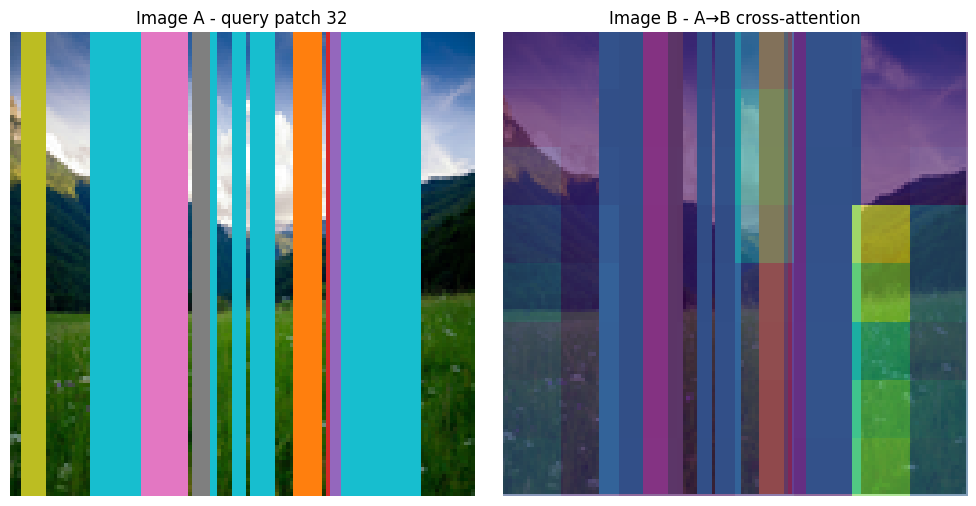

In [10]:
import matplotlib.pyplot as plt

# Select one sample and one patch in image A
sample_idx = 0

# Patch index 0..63
query_patch = 32

# Average attention over heads
attention = attn_ab[sample_idx].mean(dim=0)

# A patch -> B tokens
patch_start = 1 + model.backbone.num_register_tokens

patch_to_patch = attention[ patch_start + query_patch, patch_start: ]

# Reshape 64 patch weights -> 8x8 grid
grid_size = model.backbone.patch_embed.grid_size

attention_map = patch_to_patch.reshape( grid_size, grid_size, ).cpu().numpy()

img_a_np = img_a[sample_idx].detach().cpu().permute(1, 2, 0).numpy()
img_b_np = img_b[sample_idx].detach().cpu().permute(1, 2, 0).numpy()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_a_np)
axes[0].set_title(f"Image A - query patch {query_patch}")
axes[0].axis("off")

axes[1].imshow(img_b_np)
axes[1].imshow( attention_map, alpha=0.6, extent=(0, img_b_np.shape[1], img_b_np.shape[0], 0), )
axes[1].set_title("Image B - A→B cross-attention")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
def score_one_head(attention, vision_query, vision_target, image_width, grid_size, num_register_tokens):
    patch_start = 1 + num_register_tokens

    attn = attention[patch_start:, patch_start:]
    attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-8)
    attn = attn.detach().cpu().numpy()

    query_ids = unique_cylinder_bins(vision_query)
    target_ids = unique_cylinder_bins(vision_target)
    shared_ids = set(query_ids) & set(target_ids)

    results = []

    for cylinder_id in shared_ids:
        q_bin = query_ids[cylinder_id]
        t_bin = target_ids[cylinder_id]

        q_cols = cylinder_patch_columns(vision_query, q_bin, image_width, grid_size)
        t_cols = cylinder_patch_columns(vision_target, t_bin, image_width, grid_size)

        if not q_cols or not t_cols:
            continue

        q_indices = patch_indices_for_columns(q_cols, grid_size)

        cylinder_attention = attn[q_indices].mean(axis=0)
        grid = cylinder_attention.reshape(grid_size, grid_size)
        column_attention = grid.sum(axis=0)

        predicted_col = int(np.argmax(column_attention))
        correct_mass = float(column_attention[t_cols].sum())
        uniform_mass = len(t_cols) / grid_size

        results.append({
            "hit": predicted_col in t_cols,
            "lift": correct_mass / uniform_mass,
        })

    return results


def evaluate_layer_heads(loader, max_batches=5):
    model.eval()
    scores = {}

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= max_batches:
            break

        if len(batch) == 5:
            pairs = [(batch[0], batch[1], batch[2], batch[3])]
        else:
            pairs = [
                (batch[0], batch[1], batch[2], batch[3]),
                (batch[5], batch[6], batch[7], batch[8]),
            ]

        for img_a, vision_a, img_b, vision_b in pairs:
            with torch.no_grad():
                _, _, _, attn_ab_all, attn_ba_all = model(
                    img_a.to(device),
                    img_b.to(device),
                    return_attention=True,
                )

            grid_size = model.backbone.patch_embed.grid_size
            n_regs = model.backbone.num_register_tokens
            image_width = img_a.shape[-1]

            for layer_idx, (attn_ab, attn_ba) in enumerate(zip(attn_ab_all, attn_ba_all)):
                num_heads = attn_ab.shape[1]

                for head_idx in range(num_heads):
                    key = (layer_idx, head_idx)
                    scores.setdefault(key, [])

                    for i in range(img_a.shape[0]):
                        va = vision_a[i].cpu().numpy()
                        vb = vision_b[i].cpu().numpy()

                        scores[key] += score_one_head(
                            attn_ab[i, head_idx], va, vb,
                            image_width, grid_size, n_regs,
                        )

                        scores[key] += score_one_head(
                            attn_ba[i, head_idx], vb, va,
                            image_width, grid_size, n_regs,
                        )

    return scores


def print_head_scores(scores, name):
    print(f"\n{name}")
    print("Layer Head   Hit rate   Lift")
    print("--------------------------------")

    for (layer, head), results in sorted(scores.items()):
        hit = np.mean([r["hit"] for r in results])
        lift = np.mean([r["lift"] for r in results])

        print(f"{layer:5d} {head:4d}   {100 * hit:7.1f}%   {lift:5.2f}x")


train_scores = evaluate_layer_heads(train_loader, max_batches=5)
val_scores = evaluate_layer_heads(val_loader, max_batches=5)

print_head_scores(train_scores, "TRAIN")
print_head_scores(val_scores, "VALIDATION")


TRAIN
Layer Head   Hit rate   Lift
--------------------------------
    0    0      15.6%    0.90x
    0    1      17.9%    0.98x
    0    2      17.0%    0.90x
    0    3      18.5%    0.97x
    1    0      16.5%    0.92x
    1    1      19.1%    1.04x
    1    2      11.6%    0.77x
    1    3      17.1%    0.92x
    2    0      14.6%    0.80x
    2    1      17.7%    1.00x
    2    2      11.9%    0.75x
    2    3      13.5%    0.81x
    3    0      18.3%    1.04x
    3    1      16.1%    0.84x
    3    2      16.4%    0.94x
    3    3      12.3%    0.76x

VALIDATION
Layer Head   Hit rate   Lift
--------------------------------
    0    0      16.8%    0.94x
    0    1      20.0%    1.04x
    0    2      17.7%    0.88x
    0    3      20.5%    0.99x
    1    0      13.3%    0.77x
    1    1      20.4%    1.06x
    1    2      12.2%    0.80x
    1    3      17.4%    0.89x
    2    0      14.4%    0.79x
    2    1      15.1%    0.94x
    2    2      12.1%    0.74x
    2    3      14.8

## Training plots

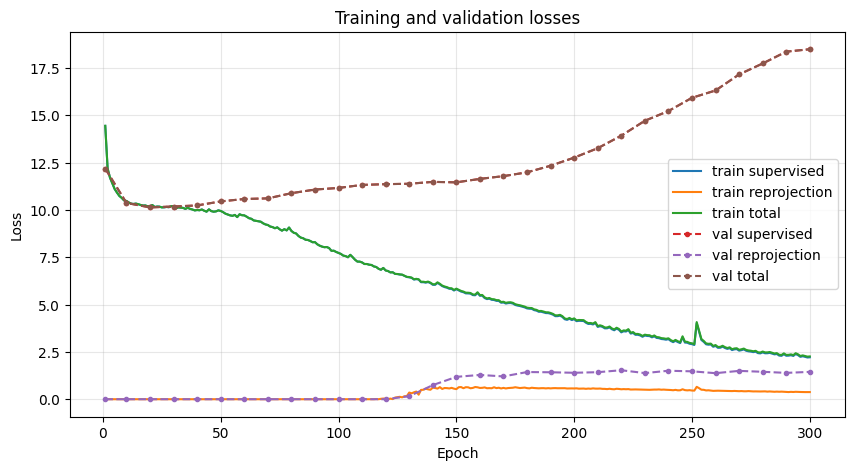

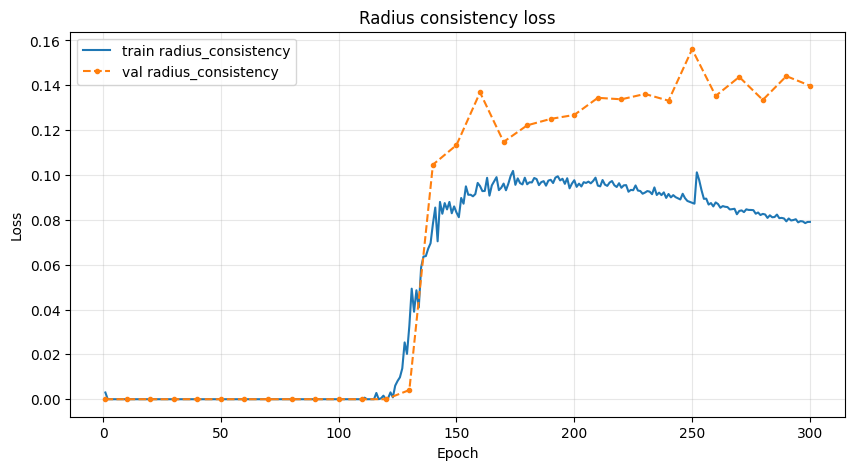

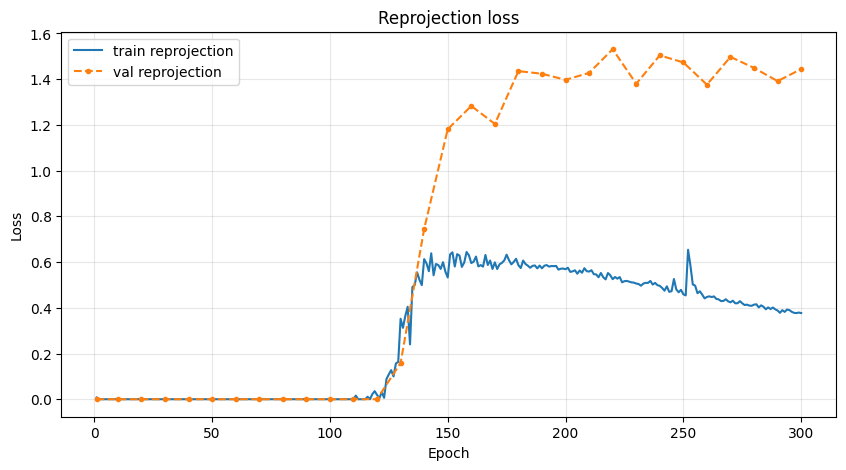

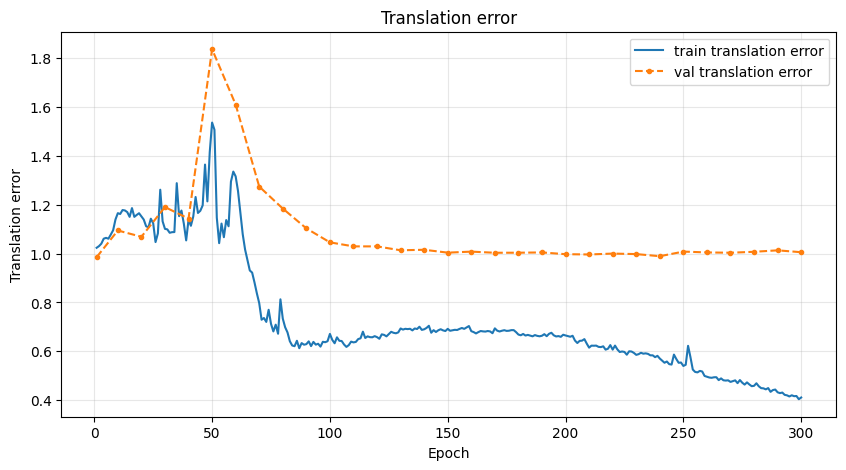

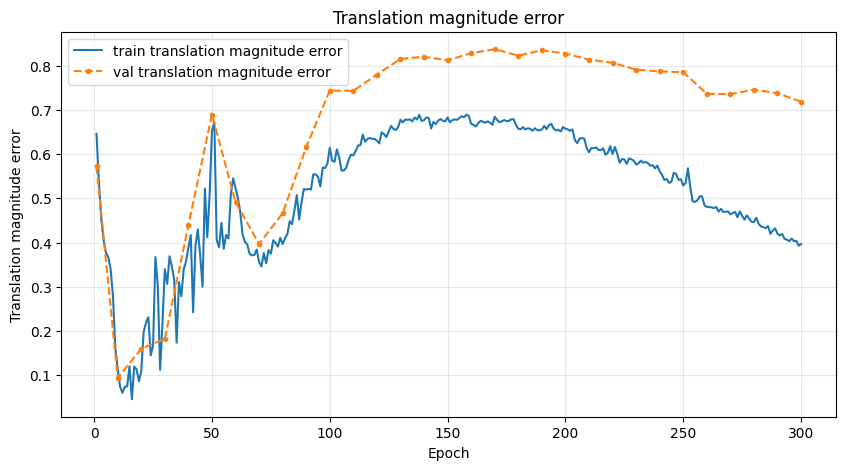

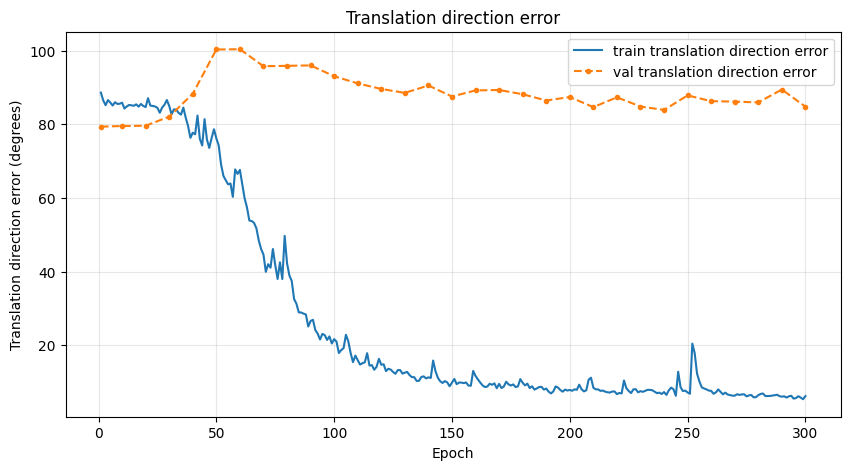

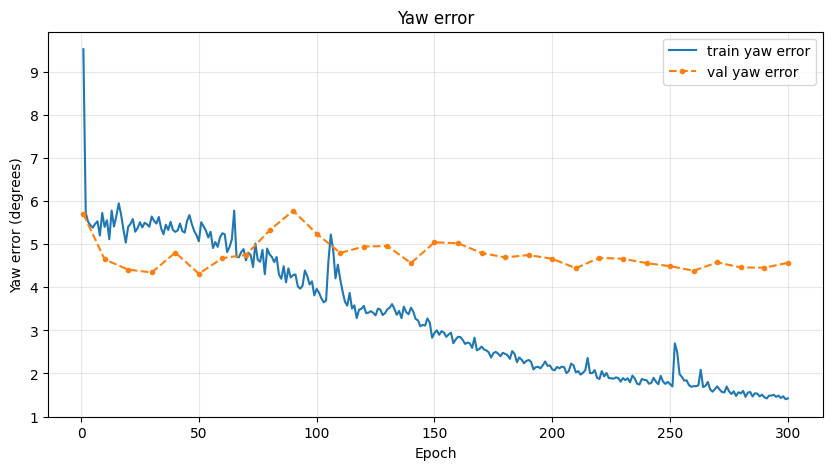

In [11]:
epochs = np.array(history["epoch"])
val_epochs = np.array(history["val_epoch"])
forest_epochs = np.array(history["forest_epoch"])

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["supervised"], label="train supervised")
plt.plot(epochs, history["reprojection"], label="train reprojection")
plt.plot(epochs, history["total"], label="train total")


if FOREST_ENABLED and len(forest_epochs) > 0:
    plt.plot(forest_epochs, history["forest_total"], "--", label="forest total")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_supervised"], ".--", label="val supervised")
    plt.plot(val_epochs, history["val_reprojection"], ".--", label="val reprojection")
    plt.plot(val_epochs, history["val_total"], ".--", label="val total")

if FOREST_ENABLED:
    plt.axvline(FOREST_START_EPOCH, linestyle=":", alpha=0.5, label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["radius_consistency"], label="train radius_consistency")

if FOREST_ENABLED and len(forest_epochs) > 0:
    plt.plot( forest_epochs, history["forest_radius_consistency"], "--", label="forest radius_consistency", )

if len(val_epochs) > 0:
    plt.plot( val_epochs, history["val_radius_consistency"], ".--", label="val radius_consistency", )

if FOREST_ENABLED:
    plt.axvline(FOREST_START_EPOCH, linestyle=":", alpha=0.5, label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Radius consistency loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["reprojection"], label="train reprojection")

if FOREST_ENABLED and len(forest_epochs) > 0:
    plt.plot( forest_epochs, history["forest_reprojection"], "--", label="forest reprojection", )

if len(val_epochs) > 0:
    plt.plot( val_epochs, history["val_reprojection"], ".--", label="val reprojection", )

if FOREST_ENABLED:
    plt.axvline(FOREST_START_EPOCH, linestyle=":", alpha=0.5, label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reprojection loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["translation_error"], label="train translation error")
if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_translation_error"], ".--", label="val translation error")
plt.xlabel("Epoch")
plt.ylabel("Translation error")
plt.title("Translation error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["translation_magnitude_error"], label="train translation magnitude error")
if len(val_epochs) > 0:
    plt.plot( val_epochs, history["val_translation_magnitude_error"], ".--", label="val translation magnitude error", )
plt.xlabel("Epoch")
plt.ylabel("Translation magnitude error")
plt.title("Translation magnitude error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["translation_direction_error"], label="train translation direction error")
if len(val_epochs) > 0:
    plt.plot( val_epochs, history["val_translation_direction_error"], ".--", label="val translation direction error", )
plt.xlabel("Epoch")
plt.ylabel("Translation direction error (degrees)")
plt.title("Translation direction error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["yaw_error_deg"], label="train yaw error")
if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_yaw_error_deg"], ".--", label="val yaw error")
plt.xlabel("Epoch")
plt.ylabel("Yaw error (degrees)")
plt.title("Yaw error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Inference on test data

In [12]:
# Choose the model used for test/inference:
#   "best"   -> checkpoint with lowest validation loss
#   "latest" -> weights from the final training epoch
# This is independent of whether the best checkpoint is loaded later.
INFERENCE_MODEL = INFERENCE_MODEL.lower()
print(f"INFERENCE_MODEL: {INFERENCE_MODEL}")
if INFERENCE_MODEL not in {"best", "latest"}:
    raise ValueError("INFERENCE_MODEL must be either 'best' or 'latest'")

if INFERENCE_MODEL == "best":
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print( f"Using BEST model from epoch {checkpoint['epoch']} " f"with val_total={checkpoint['best_val_loss']:.6f}" )
else:
    model.load_state_dict(latest_model_state_dict)
    print(f"Using LATEST model from epoch {NUM_EPOCHS}")

model.eval()

infer_dataset = SceneTwoPairsDataset( root_dir="testdataset", return_two_pairs=False, )
infer_loader = DataLoader( infer_dataset, batch_size=INFERENCE_BATCH_SIZE, shuffle=True, num_workers=0, )

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_vision_b, pred_pose = model(img_a, img_b)

if INFERENCE_SHOW_TEXT:
    n_show = min(4, img_a.shape[0])
    for i in range(n_show):
        print(f"Sample {i}")
        print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
        print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))
        pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
        print( f"  |err|: tx={pose_err[0]:.3f}, " f"ty={pose_err[1]:.3f}, " f"sin={pose_err[2]:.3f}, " f"cos={pose_err[3]:.3f}" )
        print()

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[VISION_SAMPLE_IDX].detach().cpu())
print("Pred pose:", pred_pose[VISION_SAMPLE_IDX].detach().cpu())


INFERENCE_MODEL: latest
Using LATEST model from epoch 300
pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.6748, -0.7380,  0.0924,  0.9957])
Pred pose: tensor([-0.0243,  0.2484,  0.0146,  0.9999])


## Vision prediction plots

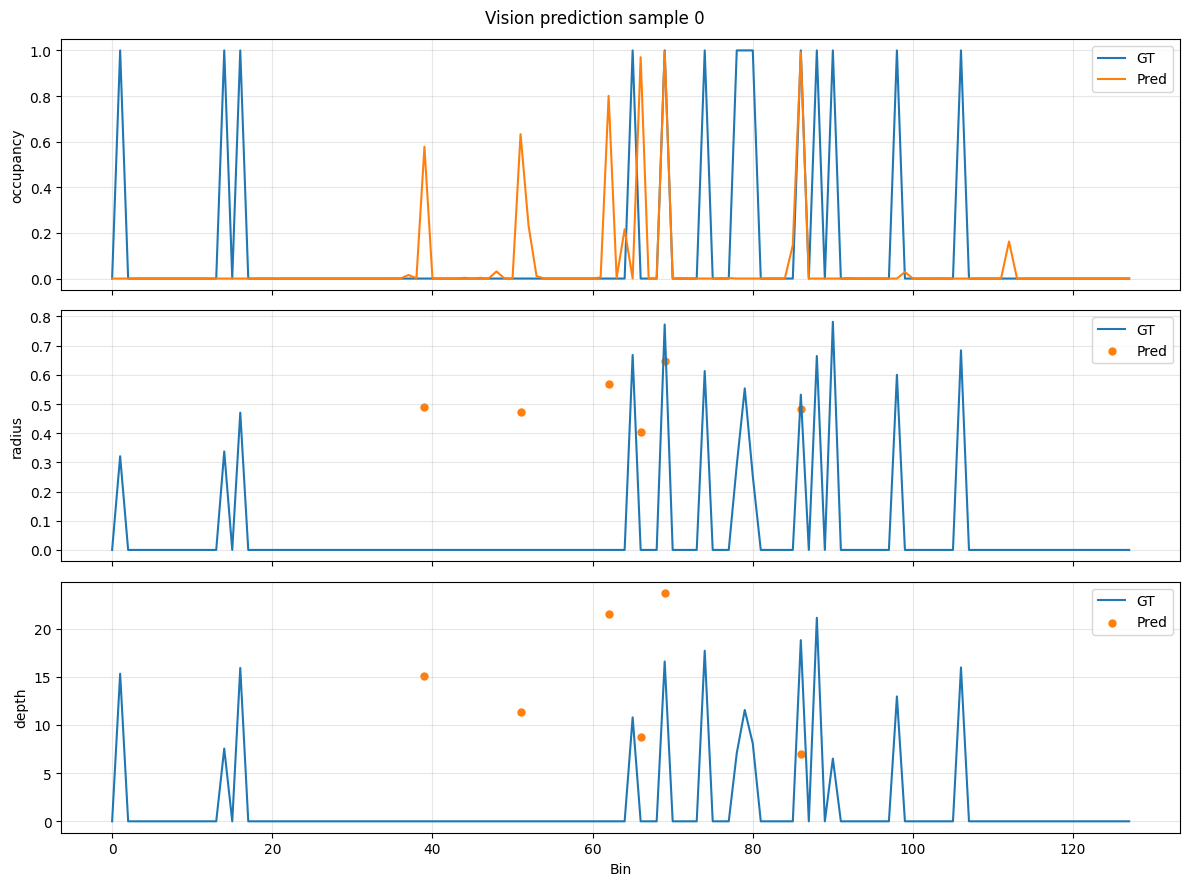

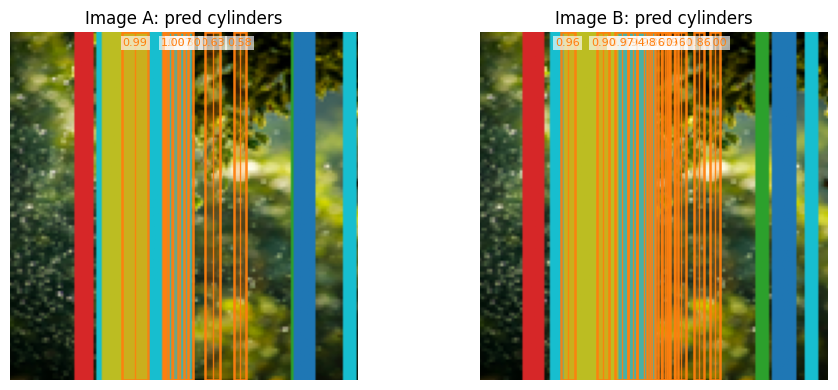

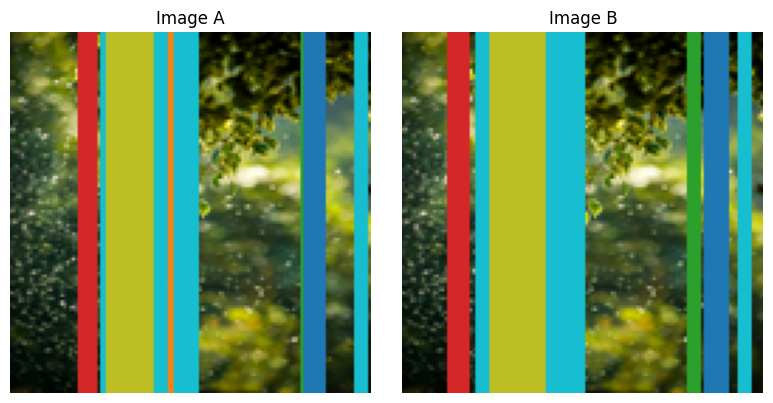

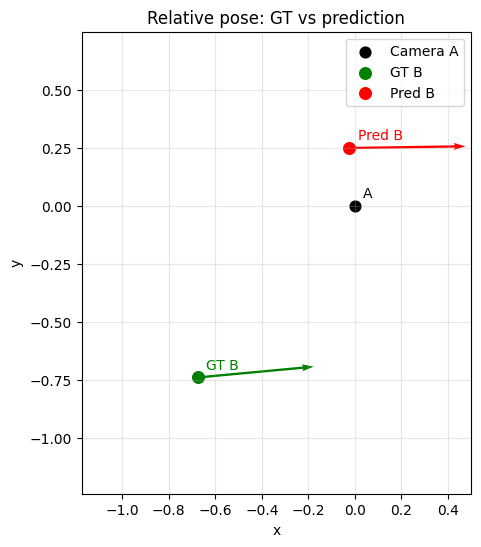

In [13]:
sample_idx = VISION_SAMPLE_IDX
bins = np.arange(pred_vision.shape[1])
occ_threshold = OCC_THRESH

if INFERENCE_SHOW_IMAGES:
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    names = ["occupancy", "radius", "depth"]

    gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
    pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

    for j, ax in enumerate(axes):
        gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
        pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

        ax.plot(bins, gt, label="GT", color="tab:blue")

        if j == 0:
            ax.plot(bins, pr, label="Pred", color="tab:orange")
        else:
            pr_mask = pr_occ > occ_threshold
            ax.scatter( bins[pr_mask], pr[pr_mask], label="Pred", color="tab:orange", s=25, )

        ax.set_ylabel(names[j])
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Bin")
    fig.suptitle(f"Vision prediction sample {sample_idx}")
    plt.tight_layout()
    plt.show()

    fig_cyl, axes_cyl = plot_estimated_cylinders_on_images(
        [img_a[sample_idx], img_b[sample_idx]],
        [pred_vision[sample_idx], pred_vision_b[sample_idx]],
        titles=["Image A: pred cylinders", "Image B: pred cylinders"],
        occ_threshold=occ_threshold,
        flip_x=True,
    )
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")
    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])


## Forest visualization

In [14]:
if FOREST_ENABLED:
    forest_sample_idx = FOREST_SAMPLE_IDX
    model.eval()
    forest_batch = next(iter(forest_loader))
    img_a_forest, img_b_forest, _ = forest_batch

    img_a_forest = img_a_forest.to(device)
    img_b_forest = img_b_forest.to(device)

    with torch.no_grad():
        pred_vision_a_forest, pred_vision_b_forest, pred_pose_forest = model( img_a_forest, img_b_forest, )

    fig_forest_cyl, axes_forest_cyl = plot_estimated_cylinders_on_images(
        [
            img_a_forest[forest_sample_idx],
            img_b_forest[forest_sample_idx],
        ],
        [
            pred_vision_a_forest[forest_sample_idx],
            pred_vision_b_forest[forest_sample_idx],
        ],
        titles=["Forest A: pred cylinders", "Forest B: pred cylinders"],
        occ_threshold=FOREST_OCC_THRESHOLD,
        flip_x=True,
    )
    plt.show()

    print("forest pred_vision_a shape:", pred_vision_a_forest.shape)
    print("forest pred_pose shape:", pred_pose_forest.shape)
    print( "forest pred_pose:", pred_pose_forest[forest_sample_idx].detach().cpu(), )


## Notes

- `FOREST_ENABLED=False` means no forest data is loaded and no forest log/plot is produced.
- `FOREST_ENABLED=True` enables the forest metrics from `FOREST_START_EPOCH` onward.
- `USE_FOREST_IN_TOTAL_LOSS=False` preserves the original optimization behavior.
- Set `USE_FOREST_IN_TOTAL_LOSS=True` when you want the forest objective to affect gradients.
- Validation runs on epoch 1 and every `VAL_INTERVAL` epochs. The checkpoint with the lowest validation `total` loss is saved to `BEST_MODEL_PATH`.
- Test/inference uses the best validation checkpoint when `LOAD_BEST_MODEL_FOR_INFERENCE=True`.
